In [1]:
import pandas as pd


In [2]:
res.columns

NameError: name 'res' is not defined

In [3]:
res = pd.read_csv("./output/support_boost_exp5_on_oss/pipeline_results.csv")
# /BTP/BtechProject/FocusedRetriever/output/support_boost_exp4_new_scoring_function/pipeline_results.csv
rec = res["recall@20"]
cnt = res["total_answers"]
zero_recall = 0 
full_recall = 0 
partial_recall = 0 
length = len(rec) 


for recall in rec :
    if recall == 0 :
        zero_recall += 1 
    elif recall == 1 :
        full_recall+= 1 
    else :
        partial_recall += 1 

print(" zero recall     :",zero_recall/length,"\n parital recall  :" ,partial_recall/length, "\n full recall     :" ,full_recall/length) 

 zero recall     : 0.4107142857142857 
 parital recall  : 0.08928571428571429 
 full recall     : 0.5


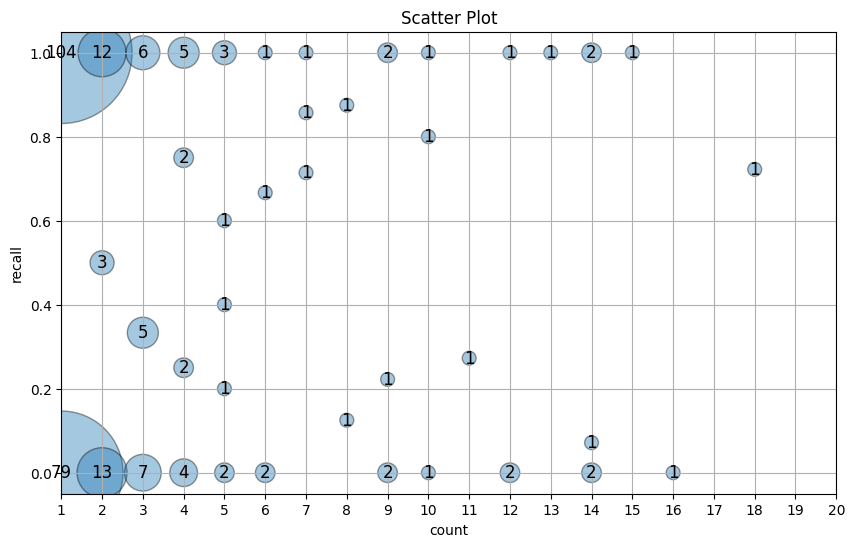

In [4]:


import pandas as pd
import matplotlib.pyplot as plt

# Suppose your series are:
# x = pd.Series(...)
# y = pd.Series(...)

df = pd.DataFrame({'x': cnt, 'y': rec})
plt.figure(figsize=(10, 6))

# Count frequency of each (x, y) pair
freq = df.value_counts().reset_index(name='count')
# Add labels for each bubble
for _, row in freq.iterrows():
    plt.text(row['x'], row['y'], str(int(row['count'])),
             fontsize=12, ha='center', va='center', color='black' )

# Scatter plot with size proportional to frequency
plt.scatter(freq['x'], freq['y'], s=freq['count'] * 100, alpha=0.4, edgecolors='k')
plt.xlabel("count")
plt.ylabel("recall")
plt.title("Scatter Plot")
plt.grid(True)
plt.xlim(1, 20)
plt.xticks(range(1, 21))
plt.show()


#  zero recall     : 0.2730627306273063 
#  parital recall  : 0.05904059040590406 
#  full recall     : 0.6678966789667896

In [ ]:
import os
import pandas as pd

def analyze_pipeline_results(verbose=True):
    # Collect all CSV files in cwd and ./output/
    search_dirs = [os.getcwd(), os.path.join(os.getcwd(), "output")]
    csv_files = []

    for d in search_dirs:
        for root, _, files in os.walk(d):
            for f in files:
                if f.endswith(".csv") and f.endswith("pipeline_results.csv"):
                    csv_files.append(os.path.join(root, f))

    if not csv_files:
        print("No *_pipeline_results.csv files found.")
        return

    for path in csv_files:
        try:
            res = pd.read_csv(path)
            if "recall@20" not in res.columns:
                if verbose:
                    print(f"⚠️ Skipping {path} (no recall@20 column).")
                continue

            rec = res["recall@100"].fillna(0)
            length = len(rec)
            zero_recall = (rec == 0).sum()
            full_recall = (rec == 1).sum()
            partial_recall = length - zero_recall - full_recall

            avg_recall = rec.mean()
            median_recall = rec.median()
            min_recall = rec.min()
            max_recall = rec.max()
            std_recall = rec.std()

            print(f"\n📄 File: {path}")
            print(f"Total samples: {length}")
            print(f"Zero recall (0.0): {zero_recall} ({zero_recall/length:.2%})")
            print(f"Full recall (1.0): {full_recall} ({full_recall/length:.2%})")
            print(f"Partial recall (0<r<1): {partial_recall} ({partial_recall/length:.2%})")
            print(f"Average recall: {avg_recall:.4f}")
            print(f"Median recall: {median_recall:.4f}")
            print(f"Min recall: {min_recall:.4f}, Max recall: {max_recall:.4f}, Std: {std_recall:.4f}")

            # Extra descriptive stats on partial recall
            partial_values = rec[(rec > 0) & (rec < 1)]
            if len(partial_values) > 0:
                print(f"  └─ Partial recall range: {partial_values.min():.4f} – {partial_values.max():.4f}")
                print(f"  └─ Partial recall mean: {partial_values.mean():.4f}, std: {partial_values.std():.4f}")
                quantiles = partial_values.quantile([0.25, 0.5, 0.75])
                print(f"  └─ Partial recall quartiles: Q1={quantiles[0.25]:.4f}, Q2={quantiles[0.5]:.4f}, Q3={quantiles[0.75]:.4f}")

        except Exception as e:
            print(f"❌ Error reading {path}: {e}")

# Run it
analyze_pipeline_results()


⚠️ Skipping /home/sarthak/BTP/BTechProject/output/exp1_pipeline_results.csv (no recall@20 column).
❌ Error reading /home/sarthak/BTP/BTechProject/output/considering_support_to_update_weights_temp/pipeline_results.csv: 'recall@100'
❌ Error reading /home/sarthak/BTP/BTechProject/output/support_boost_exp7/pipeline_results.csv: 'recall@100'
❌ Error reading /home/sarthak/BTP/BTechProject/output/support_boost_exp3/pipeline_results.csv: 'recall@100'
⚠️ Skipping /home/sarthak/BTP/BTechProject/output/oss-correct-queries/pipeline_results.csv (no recall@20 column).
❌ Error reading /home/sarthak/BTP/BTechProject/output/support_boost_exp6/pipeline_results.csv: 'recall@100'
❌ Error reading /home/sarthak/BTP/BTechProject/output/support_boost_exp5_scoring_fn_like4_more_candidates/pipeline_results.csv: 'recall@100'

📄 File: /home/sarthak/BTP/BTechProject/output/support_boost_exp8/pipeline_results.csv
Total samples: 256
Zero recall (0.0): 57 (22.27%)
Full recall (1.0): 177 (69.14%)
Partial recall (0<r<1

In [ ]:
import os
import pandas as pd

def aggregate_results(verbose=True):
    # Collect all CSV files in cwd and ./output/
    search_dirs = [os.path.join(os.getcwd(), "output/QUERY_EXPANSION_WITH_LLM_CALLS_alpha_15/"), os.path.join(os.getcwd(), "output/QUERY_EXPANSION_WITH_LLM_CALLS_alpha_5/")
    os.path.join(os.getcwd(), "output/QUERY_EXPANSION_WITH_LLM_CALLS/") , os.path.join(os.getcwd(), "output/QUERY_EXPANSION/")
    ]
    csv_files = []

    for d in search_dirs:
        for root, _, files in os.walk(d):
            for f in files:
                # print(f)
                if f.endswith(".csv") and f.endswith("pipeline_results.csv")  :
                    csv_files.append(os.path.join(root, f))

    if not csv_files:
        print("No *_pipeline_results.csv files found.")
        return

    for path in csv_files:
        try:
        # Load the CSV file
            df = pd.read_csv(path)

            # Define the columns you want to aggregate
            metric_cols = [
                'total_answers', 'retrieved_count', 'missed_count', 
                'recall@50', 'recall@20', 'hit@1', 'hit@5', 'mrr', 'recall@20_vss_merged'
            ]

            # Calculate the mean
            aggregates = df[metric_cols].mean()

            # Print results
            print(f"\n📄 File: {path}")
            print(aggregates)
        except Exception as e:
            print(f"❌ Error reading {path}: {e}")

In [11]:
aggregate_results()


📄 File: /home/sarthak/BTP/BTechProject/output/QUERY_EXPANSION_WITH_LLM_CALLS_alpha_15/pipeline_results.csv
total_answers           2.458955
retrieved_count         1.298507
missed_count            1.160448
recall@50               0.626678
recall@20               0.626678
hit@1                   0.358209
hit@5                   0.507463
mrr                     0.430988
recall@20_vss_merged    0.672352
dtype: float64


In [ ]:
import pandas as pd

from custom_pipeline.entity_parsing import parse_entity_response
from custom_pipeline.relation_parsing import parse_relation_string
df = pd.read_csv('./STEP2_results/full_data_dump.csv',header=0)

queries = []

import json
import ast
import math
import re

def parse_mixed(val):
    # Already parsed dict
    if isinstance(val, dict):
        return val

    # NaN or None
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return {}

    s = str(val).strip()

    # Remove one outer layer of quotes
    if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
        s = s[1:-1].strip()

    # ---- Try JSON first ----
    try:
        return json.loads(s)
    except:
        pass

    # ---- Convert JSON tokens -> Python tokens ----
    # true -> True, false -> False, null -> None
    fixed = (
        s.replace("true", "True")
         .replace("false", "False")
         .replace("null", "None")
    )

    # ---- Try Python literal ----
    try:
        return ast.literal_eval(fixed)
    except:
        print("UNPARSABLE STRING:", repr(s))
        raise

stored_data = {}
for index, query in df.iterrows():
    # print(query)
    stored_data[query['id']] = {
        'id' : query['id'],
        'query' : query['query'],
        'entities' : (query['entity_id_response']),
        'relations' : (query['relations_id_response'])
    }

print(df.head())
def dummy_step1_identify_entities(current_query):
    response_string = ""
    if current_query.id in stored_data :
        response_string = stored_data[current_query.id]['entities']
        current_query.entity_id_response = response_string

    else :
        response_string = ''
    
    if response_string == '':
        current_query.status = "FAILED"
        return  # should i be doing this ??
    else:
        try:
            identified_entities = parse_entity_response(response_string)
            current_query.entities = identified_entities
        except ValueError as e:
            current_query.status = "FAILED"
            print(f"Error parsing response for query {e}")

# def step1_identify_entities(query: Query) :
    
#     query.entity_id_response = response_string
#     if response_string == '' :
#         query.status = "FAILED"
#         return # should i be doing this ??
#     else :
#         try :
#             identified_entities = parse_entity_response(response_string)
#             query.entities = identified_entities
#         except ValueError as e:
#             query.status = "FAILED"
#             print(f"Error parsing response for query {e}")

def dummy_step2_identify_relations(current_query) : 
    response_string = ""
    if current_query.id in stored_data :
        response_string = stored_data[current_query.id]['relations']
    else :
        response_string = ''
    current_query.relations_id_response = response_string
    if response_string == '' :
        current_query.status = "FAILED"
        return # should i be doing this ??
    else :
        try :
            identified_relations = parse_relation_string(response_string)
            current_query.relations = identified_relations
        except ValueError as e:
            current_query.status = "FAILED"
            print(f"Error parsing response for query {e}")

# def step2_identify_relations(query: Query) :
    # prompt = generate_relation_identification_prompt(query.query,str(query.entities))
    # response_string = get_llm_response(prompt)
    # query.relations_id_response = response_string

    # if response_string == '' :
    #     query.status = "FAILED"
    #     return # should i be doing this ??
    # else :
    #     try :
    #         identified_relations = parse_relation_string(response_string)
    #         query.relations = identified_relations
    #     except ValueError as e:
    #         query.status = "FAILED"
    #         print(f"Error parsing response for query {e}")

      id                                              query  \
0   6517  Which cell structures are involved in interact...   
1   9996  Which genes or proteins are expressed exclusiv...   
2   3630  Could you suggest any medications effective fo...   
3  10252  Which gene or protein responsible for coding t...   
4   5142  Which autosomal dominant diseases are linked t...   

                  ground_truths       status  \
0  [56241, 55842, 56174, 56263]  IN_PROGRESS   
1                       [10833]  IN_PROGRESS   
2                       [15179]  IN_PROGRESS   
3                    [43, 2140]  IN_PROGRESS   
4                       [30638]  IN_PROGRESS   

                                  entity_id_response  \
0  {\n  "A": {\n    "type": ["drug"],\n    "lexic...   
1  {\n  "A": {\n    "type": ["anatomy"],\n    "le...   
2  {\n  "A": {\n    "type": ["disease"],\n    "le...   
3  {\n  "A": {\n    "type": ["gene/protein", "mol...   
4  {\n  "A": {\n    "type": ["anatomy"],\n    "le...